# Hypothesis Tests: Translating Resampling Work into `scipy.stats`

Pair each simulation-based analysis with a closed-form approximation so you can tell both stories for the same question.

## How to use this notebook
- Work through the tasks in order and duplicate sections if you need more space. The README has more guidance.
- Keep large/raw data out of Git; load it from your local data directory.
- Replace the placeholder code cells with working code, then summarize findings in the surrounding markdown.
- When finished, restart the kernel, run all cells, and double-check that everything executes cleanly.

## Frequentist toolbox reminder
You may find these patterns handy when translating permutation work into CLT-style stats:
- `scipy.stats`: `ttest_ind`, `ttest_rel`, `norm`, `t`, `binomtest`, `chi2`.
- Standard errors: `sample_std / np.sqrt(n)` for means, `np.sqrt(p * (1 - p) / n)` for proportions.
- `statsmodels.stats.proportion.proportion_confint` for Wald/score intervals on proportions.
- `scipy.stats.sem` or `DescrStatsW` for weighted summaries.
- Use `stats.norm.cdf` / `ppf` for quick p-values or critical values when assumptions are reasonable.

## Getting Started
Duplicate or remove task sections as needed.

### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

### Data loading
Point these at the datasets you need for the tasks below.

In [2]:
car_listings = pd.read_csv('car_listings.csv')
satisfaction = pd.read_csv('satisfaction_survey.txt', sep = '\t')
credit_union = pd.read_csv('wsecu_survey_data.txt', sep ='\t', index_col=0)

## Task 1

If this task is going to be a hypothesis test, briefly describe the hypothesis and dataset. If this task is going to be the calculation of an uncertainty, describe the metric and data. If this is the uncertainty calculation where you'll choose an additional metric other than the mean or a proportion, describe that metric as well.

Test whether the mean asking price of Ford F-150 listings in Duluth is greater than mean asking price in Minneapolis using car_listings.
Dataset: car_listings.csv filtered for Ford F-150s, using price by location (Duluth vs Minneapolis).

### Computational Approach

Briefly describe the resampling or permutation workflow you'll use.

In [3]:
# Your code here
car_listings.head()

,url,location,post_id,time_posted,name,make,model,year,odometer,title,...,type,transmission,condition,vin,price,posting_body_text,title_text,num_images,latitude,longitude
0,https://fargo.craigslist.org/cto/d/west-fargo-...,fargo,7787882335,2024-09-25 09:35:39+00:00,chevy equinox lt awd,chevrolet,equinox,2013.0,160000.0,clean,...,SUV,automatic,NaN,NaN,6000.0,\n\nQR Code Link to This Post\n\n\n14 Equinox ...,14 Chevy Equinox,11.0,46.890700,-96.925800
1,https://chicago.craigslist.org/nwc/cto/d/des-p...,chicago,7789338453,2024-09-30 12:25:28+00:00,ford transit,ford,transit 250 van,2019.0,93000.0,clean,...,van,automatic,good,NaN,21900.0,\n\nQR Code Link to This Post\n\n\n2019 Ford C...,2019 FORD TRANSIT 250 VAN,14.0,42.023580,-87.902577
2,https://chicago.craigslist.org/nch/cto/d/evans...,chicago,7789384937,2024-09-30 14:33:58+00:00,ford escape titanium,ford,escape,2014.0,122000.0,clean,...,SUV,automatic,excellent,NaN,6250.0,\n\nQR Code Link to This Post\n\n\n2014 Ford E...,2014 Ford Escape (Excellent condition) Titaniu...,12.0,42.052098,-87.686005
3,https://chicago.craigslist.org/sox/cto/d/chica...,chicago,7789321782,2024-09-30 11:42:21+00:00,nissan altima 2.5 s,nissan,altima,2015.0,145000.0,clean,...,sedan,automatic,excellent,NaN,5200.0,\n\nQR Code Link to This Post\n\n\nHeres is my...,"2015 Nissan Altima S, 145k, *Remote Start*, 4 ...",11.0,41.781400,-87.770500
4,https://chicago.craigslist.org/nwi/cto/d/scher...,chicago,7789402919,2024-09-30 15:25:31+00:00,honda odyssey touring,honda,odyssey,2007.0,230000.0,clean,...,minivan,automatic,excellent,NaN,3500.0,\n\nQR Code Link to This Post\n\n\nVery Nice V...,2007 Honda Odyssey Touring,10.0,41.492200,-87.460500


In [4]:
car_listings['make'] = car_listings['make'].astype(str).str.lower()
car_listings['model'] = car_listings['model'].astype(str).str.lower()
car_listings['location'] = car_listings['location'].astype(str).str.lower()
car_listings["price"] = pd.to_numeric(car_listings["price"], errors="coerce")

In [5]:
missing_values = car_listings[['make', 'model', 'location', 'price']].isna().sum()
print(missing_values)

make            0
model           0
location        0
price       11163
dtype: int64


In [6]:
car_listings = car_listings.dropna(subset=['price'])

In [7]:
ford_150s = car_listings[
    (car_listings["make"] == "ford") &
    (car_listings["model"] == "f150") &
    (car_listings["location"].str.contains("duluth|minneapolis"))
    ].copy()

In [8]:
ford_150s.shape

(2045, 24)

In [9]:
ford_150s

,url,location,post_id,time_posted,name,make,model,year,odometer,title,...,type,transmission,condition,vin,price,posting_body_text,title_text,num_images,latitude,longitude
186,https://minneapolis.craigslist.org/wsh/cto/d/s...,minneapolis,7878590788,2025-09-02 18:11:34+00:00,ford f-150,ford,f150,2008.0,202400.0,lien,...,pickup,automatic,fair,NaN,6500.0,\n\nQR Code Link to This Post\n\n\n2008 Ford F...,2008 Ford F150,6.0,45.133100,-92.686500
258,https://minneapolis.craigslist.org/ank/cto/d/c...,minneapolis,7771539822,2024-08-01 15:40:25+00:00,ford f-150,ford,f150,2008.0,147000.0,clean,...,pickup,automatic,good,NaN,5500.0,"\n\nQR Code Link to This Post\n\n\nHey, this t...",2008 F150 XLT,8.0,45.152800,-93.144000
369,https://minneapolis.craigslist.org/hnp/cto/d/m...,minneapolis,7789478822,2024-09-30 20:13:08+00:00,ford f-150 lariat,ford,f150,2005.0,188000.0,clean,...,pickup,automatic,fair,NaN,3900.0,\n\nQR Code Link to This Post\n\n\nPickup serv...,2005 F-150 4x4 Lariat,9.0,44.937800,-93.254500
1046,https://duluth.craigslist.org/cto/d/duluth-201...,duluth,7769954513,2024-07-27 11:12:35+00:00,ford f-150,ford,f150,2010.0,190488.0,clean,...,NaN,automatic,NaN,NaN,919.0,\n\nQR Code Link to This Post\n\n\n2010 FORD F...,2010 FORD F 150 Mechanic special?,8.0,46.814700,-92.199800
1130,https://minneapolis.craigslist.org/wsh/cto/d/o...,minneapolis,7785326213,2024-09-16 13:54:52+00:00,ford f150 lariat,ford,f150,2009.0,220000.0,clean,...,pickup,automatic,good,NaN,5000.0,\n\nQR Code Link to This Post\n\n\nruns and dr...,2009 ford f150 lariat,6.0,45.318054,-92.630711
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
264980,https://minneapolis.craigslist.org/csw/cto/d/e...,minneapolis,7668571475,2023-09-21 16:22:00+00:00,2012 ford f-150,ford,f150,2012.0,180570.0,clean,...,truck,automatic,good,NaN,13500.0,\n\nQR Code Link to This Post\n\n\n***crew cab...,2012 ford f150 lariat,9.0,45.313600,-93.581400
264981,https://minneapolis.craigslist.org/hnp/cto/d/m...,minneapolis,7662216769,2023-09-04 10:01:37+00:00,2013 ford f-150,ford,f150,2013.0,144885.0,clean,...,truck,automatic,excellent,1FTFX1ET3DFA13567,18000.0,\n\nQR Code Link to This Post\n\n\nI’m selling...,For sale 2013 FORD F150,11.0,44.829577,-93.276672
264982,https://duluth.craigslist.org/cto/d/gordon-201...,duluth,7648658511,2023-07-28 19:42:09+00:00,2013 ford f-150,ford,f150,2013.0,176000.0,clean,...,pickup,automatic,good,NaN,10500.0,\n\nQR Code Link to This Post\n\n\n2013 Ford F...,2013 Ford F150 XLT Supercrew 4x4,7.0,46.233600,-91.803300
264999,https://minneapolis.craigslist.org/dak/cto/d/i...,minneapolis,7759629421,2024-06-23 10:13:06+00:00,Ford F-150 King Ranch 4x4,ford,f150,2006.0,245000.0,clean,...,pickup,automatic,fair,NaN,3800.0,\n\nQR Code Link to This Post\n\n\nOldie but G...,Ford F-150 King Ranch,8.0,44.828800,-93.039100


In [10]:
duluth_prices = ford_150s[ford_150s['location'] == 'duluth']['price'].values
minneapolis_prices = ford_150s[ford_150s['location'] == 'minneapolis']['price'].values

In [11]:
obs_diff = duluth_prices.mean() - minneapolis_prices.mean()
print(f"Observed difference (Duluth - Minneapolis): {obs_diff:.2f}")

Observed difference (Duluth - Minneapolis): 3372.86


In [12]:
combined = np.concatenate([duluth_prices, minneapolis_prices])

In [13]:
n_sim = 10000
perm_diffs = np.empty(n_sim)

for i in range(n_sim):
    np.random.shuffle(combined)
    duluth = combined[:len(duluth_prices)]
    minneapolis = combined[len(duluth_prices):]
    perm_diffs[i] = duluth.mean() - minneapolis.mean()    

In [14]:
p_value = np.mean(perm_diffs >= obs_diff)
print(f"Permutation test p-value (Duluth > Minneapolis): {p_value:.4f}")

Permutation test p-value (Duluth > Minneapolis): 0.0000


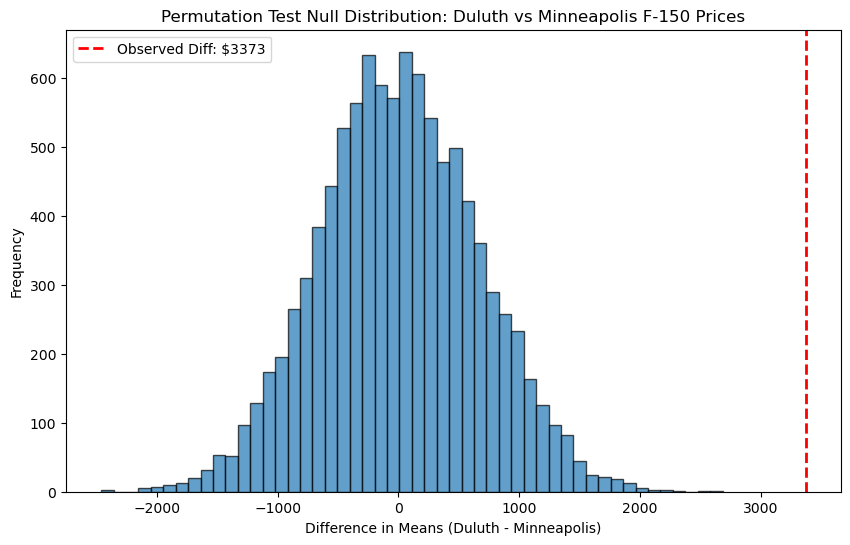

In [15]:
plt.figure(figsize=(10,6))
plt.hist(perm_diffs, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(obs_diff, color='red', linestyle='dashed', linewidth=2, label=f'Observed Diff: ${obs_diff:.0f}')
plt.xlabel('Difference in Means (Duluth - Minneapolis)')
plt.ylabel('Frequency')
plt.title('Permutation Test Null Distribution: Duluth vs Minneapolis F-150 Prices')
plt.legend()
plt.show()

### CLT Approach

Summarize how you'll approximate the sampling distribution analytically (e.g., using SE formulas).

In [16]:
# Your code here
res_price = stats.ttest_ind(duluth_prices, minneapolis_prices, equal_var=False)
print(f"T-statistic: {res_price.statistic:.3f}")
print(f"Two-sided p-value (difference in either direction): {res_price.pvalue:.4f}")

p_one_sided = res_price.pvalue / 2 if res_price.statistic > 0 else 1 - res_price.pvalue / 2
print(f"One-sided p-value (Duluth > Minneapolis): {p_one_sided:.4f}")

T-statistic: 3.888
Two-sided p-value (difference in either direction): 0.0001
One-sided p-value (Duluth > Minneapolis): 0.0001


### Comparison

Discuss how the computational and CLT approaches align or diverge.

Both the permutation test (computational approach) and the Welch’s t-test (CLT/frequentist approach) strongly support the hypothesis that Duluth F-150 prices are higher than Minneapolis. The permutation test gives a p-value zero, while the one-sided t-test p-value is 0.0001. This shows that the result is robust across both methods.
The permutation test looks at the data directly and doesn’t assume any particular shape for the prices. The t-test assumes that the average prices are roughly normal because of the Central Limit Theorem. Even though these two tests work differently, both show the same result: F-150s in Duluth are significantly more expensive than in Minneapolis. This gives us confidence in our conclusion.

## Task 2

If this task is going to be a hypothesis test, briefly describe the hypothesis and dataset. If this task is going to be the calculation of an uncertainty, describe the metric and data. If this is the uncertainty calculation where you'll choose an additional metric other than the mean or a proportion, describe that metric as well.

Estimating the uncertainty of the mean asking price of Ford F-150s. The data comes from car_listings.csv, filtered to only include Ford F-150 listings. The metric we are using is the mean price of F-150s. We use bootstrapping to calculate city-specific 95% confidence intervals, and we use the CLT to calculate a 95% confidence interval for the overall mean price across all cities.

### Computational Approach

Outline the resampling or permutation workflow you'll use.

In [17]:
ford_150s = car_listings[
    (car_listings["make"] == "ford") &
    (car_listings["model"] == "f150")
].copy()

In [18]:
# Your code here
def bootstrap(data, n_boot=1000):
    boot_means = np.empty(n_boot)
    n = len(data)
    for i in range(n_boot):
        sample = np.random.choice(data, size=n, replace=True)
        boot_means[i] = sample.mean()

    lower, upper = np.percentile(boot_means, [2.5,97.5])
    return lower, upper

In [19]:
cities = ford_150s['location'].unique()
cities.tolist()

['appleton',
 'chicago',
 'milwaukee',
 'stlouis',
 'minneapolis',
 'desmoines',
 'madison',
 'kansascity',
 'omaha',
 'duluth',
 'grandrapids',
 'fargo']

In [20]:
result = []
for city in cities:
    prices = ford_150s.loc[ford_150s['location']==city, 'price']
    lower, upper = bootstrap(prices, n_boot=1000)
    mean_price = prices.mean()
    result.append([city, mean_price, lower, upper])

In [21]:
df = pd.DataFrame(result, columns=["City", "Mean Price", "CI Lower (2.5)", "CI Upper (97.5)"])
df = df.sort_values('Mean Price', ascending=False).reset_index(drop=True)
df

,City,Mean Price,CI Lower (2.5),CI Upper (97.5)
0,duluth,13743.562310,12167.814438,15370.737842
1,fargo,12648.784753,11171.084193,14014.985874
2,desmoines,12640.342767,11377.806289,14087.611242
3,kansascity,11837.097175,11201.398333,12546.507514
4,appleton,11454.812261,10445.225192,12619.191667
5,omaha,11398.959786,10325.951676,12436.872252
6,grandrapids,10835.140523,9655.710294,12012.512663
7,madison,10428.017442,9454.933358,11395.306468
8,stlouis,10376.144522,9710.684237,11024.884557
9,minneapolis,10370.702214,9904.347247,10813.698660


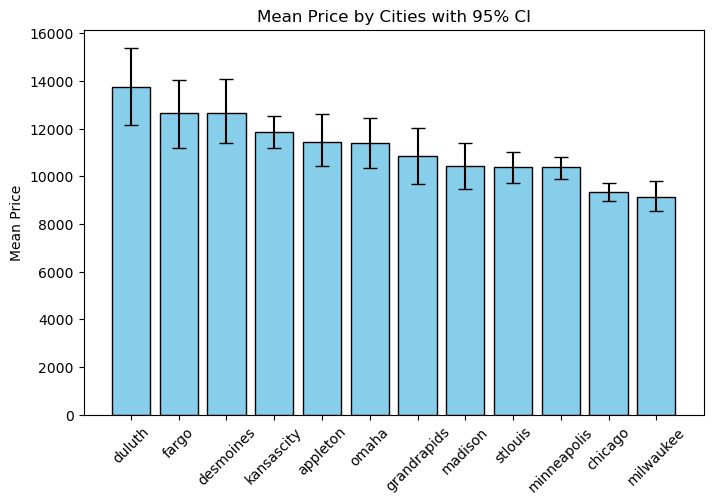

In [22]:
plt.figure(figsize=(8,5))
plt.bar(df['City'], df['Mean Price'], 
        yerr=[df['Mean Price'] - df['CI Lower (2.5)'], 
              df['CI Upper (97.5)'] - df['Mean Price']],
        capsize=5, color='skyblue', edgecolor='black')
plt.ylabel("Mean Price")
plt.title("Mean Price by Cities with 95% CI")
plt.xticks(rotation=45)
plt.show()

### CLT Approach

Summarize how you'll approximate the sampling distribution analytically (e.g., using SE formulas).

In [23]:
# Your code here
length = len(ford_150s['price'])
price_mean = ford_150s['price'].mean()
standard_error = ford_150s['price'].std(ddof=1) / np.sqrt(length) # standard_error = standard_deviation / under root (Sample_Size)
tcrit = stats.t.ppf(0.975, df=length-1)
ci_t = (price_mean - tcrit*standard_error, price_mean + tcrit*standard_error)

print(f"Mean price: {price_mean:.2f}")
print(f"95% CLT confidence interval: ({ci_t[0]:.2f}, {ci_t[1]:.2f})")

Mean price: 10649.75
95% CLT confidence interval: (10428.14, 10871.35)


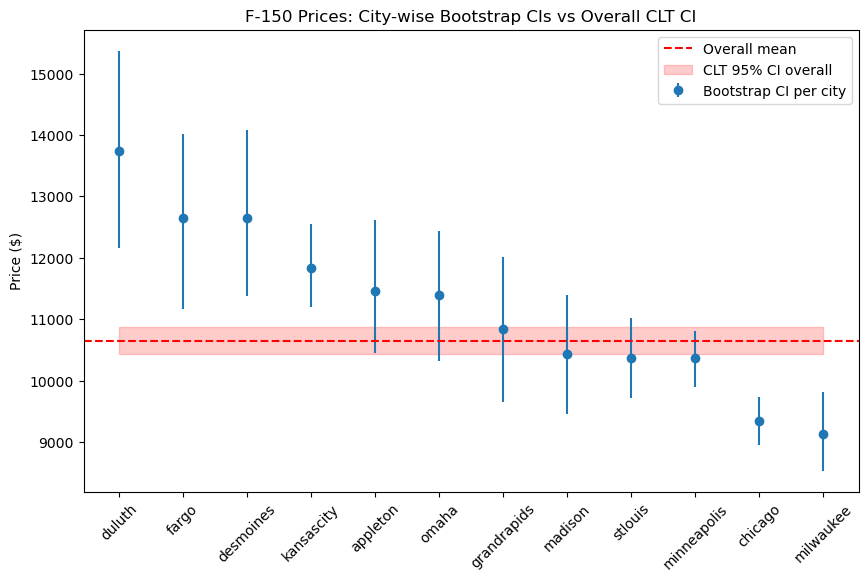

In [24]:
plt.figure(figsize=(10,6))
plt.errorbar(df['City'], df['Mean Price'], 
             yerr=[df['Mean Price'] - df['CI Lower (2.5)'], df['CI Upper (97.5)'] - df['Mean Price']],
             fmt='o', label='Bootstrap CI per city')
plt.axhline(price_mean, color='red', linestyle='--', label='Overall mean')
plt.fill_between(df['City'], ci_t[0], ci_t[1], color='red', alpha=0.2, label='CLT 95% CI overall')
plt.xticks(rotation=45)
plt.ylabel("Price ($)")
plt.title("F-150 Prices: City-wise Bootstrap CIs vs Overall CLT CI")
plt.legend()
plt.show()


### Comparison

Discuss how the computational and CLT approaches align or diverge.

The computational (bootstrap) approach provides 95% confidence intervals for the mean F-150 price for each city, showing city-specific variability and uncertainty. The CLT approach gives a single 95% confidence interval for the overall mean price across all cities. The overall mean from the CLT lies roughly within the range of many city-specific bootstrap CIs, but some cities (like Duluth or Milwaukee) have means and intervals that clearly deviate from the overall CI. So, bootstrap highlights differences between cities, while CLT summarizes the overall trend.

## Task 3

If this task is going to be a hypothesis test, briefly describe the hypothesis and dataset. If this task is going to be the calculation of an uncertainty, describe the metric and data. If this is the uncertainty calculation where you'll choose an additional metric other than the mean or a proportion, describe that metric as well.

This is a hypothesis test comparing mean satisfaction between men and women using the satisfaction_survey dataset. The goal is to test whether men have higher average satisfaction than women.

### Computational Approach

Outline the resampling or permutation workflow you'll use.

In [25]:
# Your code here
satisfaction.head()

,employee_id,gender,location,tenure,satisfaction
0,AQ1600314,man,Seattle,0.9,4
1,AQ1808649,man,Seattle,4.3,4
2,AQ1850081,man,New York,1.2,4
3,AQ1929192,man,Seattle,1.5,4
4,AQ1238345,man,New York,NaN,4


In [26]:
satisfaction.isna().sum()

employee_id     0
gender          3
location        5
tenure          2
satisfaction    0
dtype: int64

In [27]:
satisfaction["gender"] =  satisfaction["gender"].apply(lambda x: str(x) if pd.notnull(x) else None)
satisfaction["location"] = satisfaction["location"].apply(lambda s: str(s) if pd.notnull(s) else None)

In [28]:
satisfaction["tenure"] = satisfaction["tenure"].fillna(satisfaction["tenure"].mean())
satisfaction["tenure"] = satisfaction["tenure"].round(2)

In [29]:
satisfaction["gender"] = satisfaction["gender"].fillna(satisfaction["gender"].mode()[0])
satisfaction["location"] = satisfaction["location"].fillna(satisfaction["location"].mode()[0])

In [30]:
satisfaction["gender"].value_counts()

gender
man        184
woman      106
neither     10
Name: count, dtype: int64

In [31]:
satisfaction_mean = satisfaction.groupby("gender")["satisfaction"].mean()
print(satisfaction_mean)

gender
man        4.195652
neither    3.300000
woman      3.622642
Name: satisfaction, dtype: float64


In [32]:
observed_differences = satisfaction_mean["man"] - satisfaction_mean["woman"]
print(f"Observed difference: {observed_differences:.2f}")

Observed difference: 0.57


In [33]:
subset = satisfaction[satisfaction["gender"].isin(["man", "woman"])].copy()
satisfaction_values = subset["satisfaction"].values
gender_labels = subset["gender"].values

In [34]:
n_sim = 1000
perm_diffs = np.empty(n_sim)

for i in range(n_sim):
    shuffled = np.random.permutation(gender_labels)
    mean_man = satisfaction_values[shuffled == "man"].mean()
    mean_woman = satisfaction_values[shuffled == "woman"].mean()
    perm_diffs[i] = mean_man - mean_woman  

In [35]:
p_value = np.mean(perm_diffs >= observed_differences)
print(f"Permutation test p-value (man > woman): {p_value:.4f}")

Permutation test p-value (man > woman): 0.0000


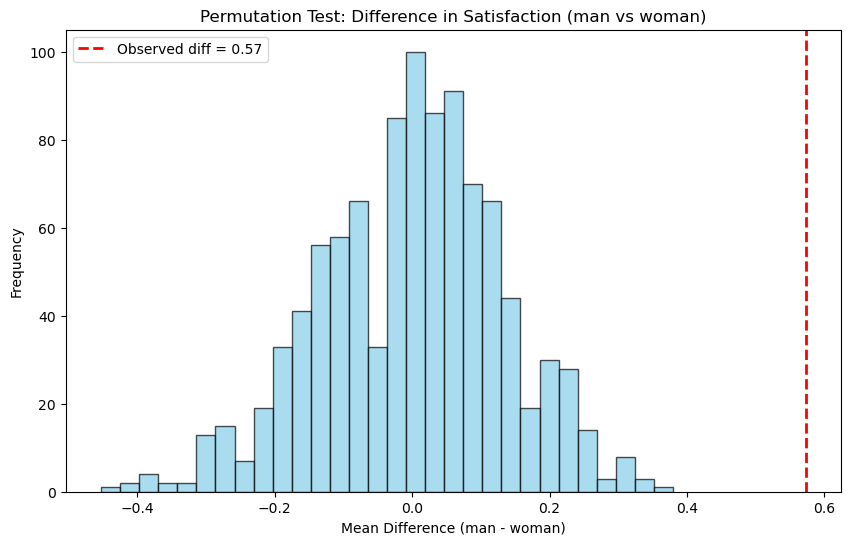

In [36]:
plt.figure(figsize=(10,6))
plt.hist(perm_diffs, bins=30, color='skyblue', edgecolor='k', alpha=0.7)
plt.axvline(observed_differences, color='red', linestyle='--', linewidth=2, label=f'Observed diff = {observed_differences:.2f}')
plt.xlabel("Mean Difference (man - woman)")
plt.ylabel("Frequency")
plt.title("Permutation Test: Difference in Satisfaction (man vs woman)")
plt.legend()
plt.show()

### CLT Approach

Summarize how you'll approximate the sampling distribution analytically (e.g., using SE formulas).

In [37]:
# Your code here
man_satisfaction = subset[subset["gender"] == "man"]["satisfaction"]
woman_satisfaction = subset[subset["gender"] == "woman"]["satisfaction"]

t_stat, p_two_sided = stats.ttest_ind(man_satisfaction, woman_satisfaction, equal_var=False)
p_one_sided = p_two_sided / 2 if t_stat > 0 else 1 - p_two_sided / 2

print(f"T-statistic: {t_stat:.4f}")
print(f"Two-sided p-value {p_two_sided:.4f}")
print(f"One-sided p-value (man > woman): {p_one_sided:.4f}")

T-statistic: 4.4734
Two-sided p-value 0.0000
One-sided p-value (man > woman): 0.0000


### Comparison

Discuss how the computational and CLT approaches align or diverge.

Both the computational (permutation) and CLT (t-test) approaches lead to the same conclusion: men have significantly higher satisfaction than women. The permutation test estimates the significance by shuffling the data many times, showing how extreme the observed difference is compared to chance. The CLT approach uses formulas to calculate a t-statistic and p-value. Both align in results and both show that the difference is highly significant.

## Task 4

If this task is going to be a hypothesis test, briefly describe the hypothesis and dataset. If this task is going to be the calculation of an uncertainty, describe the metric and data. If this is the uncertainty calculation where you'll choose an additional metric other than the mean or a proportion, describe that metric as well.

Test the hypothesis that the East region has higher mean progressivism than the West region using the credit union survey data, grouping the five regions into East and West.

### Computational Approach

Outline the resampling or permutation workflow you'll use.

In [38]:
# Your code here
credit_union.head()

,id,age,gender,engagement,mem.edu,zip,channel,harm,fair,in.group,authority,purity,account.age,region,public.sector,sustainability,localism,main.focal.value,support.of.focal.value
0,346,56,other,Engaged,2,98503.0,Branch,1.00,1.00,1.00,1.00,1.25,9.951,Thurston,yes,2.333333,2.75,Homelessness,0.000000
1,348,66,female,Highly Engaged,3,98012.0,Branch,5.00,4.75,2.25,3.25,2.25,8.838,W WA Metro,yes,6.000000,5.75,Environment,18.627830
2,349,71,male,Not Engaged,7,98506.0,Branch,3.25,4.25,2.25,3.25,2.75,5.356,Thurston,yes,5.166667,4.50,Hunger/Poverty,28.739986
3,352,66,male,Engaged,7,NaN,Branch,4.25,4.75,4.75,3.25,3.75,9.192,W WA Metro,no,5.500000,4.50,Education,18.055372
4,358,50,male,Highly Engaged,4,98233.0,Branch,2.00,4.50,3.50,4.50,3.25,11.570,W WA Non Metro,yes,2.833333,4.00,Education,4.400921


In [39]:
credit_union.isna().sum()

id                          0
age                         0
gender                      0
engagement                  0
mem.edu                     0
zip                       239
channel                     0
harm                        0
fair                        0
in.group                    0
authority                   0
purity                      0
account.age                 0
region                      0
public.sector               0
sustainability              0
localism                    0
main.focal.value            0
support.of.focal.value      0
dtype: int64

In [40]:
credit_union['zip'] = credit_union.groupby('region')['zip'].transform(lambda x: x.fillna(x.median()))

In [42]:
credit_union["progressivism"] = ((credit_union['harm'] + credit_union['fair']) / 2) - ((credit_union['purity'] + credit_union['in.group'] + credit_union['authority']) / 3)

In [43]:
credit_union['progressivism'].describe()

count    2421.000000
mean        0.920487
std         0.975008
min        -2.458333
25%         0.250000
50%         0.791667
75%         1.500000
max         4.375000
Name: progressivism, dtype: float64

In [44]:
credit_union['region'].value_counts()

region
W WA Metro        924
Thurston          725
E WA Non Metro    315
W WA Non Metro    276
E WA Metro        181
Name: count, dtype: int64

In [45]:
east_regions = ["E WA Metro", "E WA Non Metro"]
west_regions = ["W WA Metro", "W WA Non Metro", "Thurston"]

In [46]:
east_data = credit_union.loc[credit_union['region'].isin(east_regions), "progressivism"]
west_data = credit_union.loc[credit_union["region"].isin(west_regions), "progressivism"]
print(f"Sample sizes:")
print(f"  East WA: n = {len(east_data)}")
print(f"  West WA: n = {len(west_data)}")

Sample sizes:
  East WA: n = 496
  West WA: n = 1925


In [47]:
o_diff = east_data.mean() - west_data.mean()
print(f'Observed Difference (east - west) -> {o_diff:.2f}')

Observed Difference (east - west) -> -0.36


In [48]:
combined_data = np.concatenate([east_data.values, west_data.values])

In [49]:
sim = 1000
diffs_perm = np.empty(sim)

for i in range(sim):
    np.random.shuffle(combined_data)
    east = combined_data[:len(east_data)]
    west = combined_data[len(east_data):]
    diffs_perm[i] = east.mean() - west.mean()

In [52]:
p_values = np.mean(np.abs(diffs_perm) >= np.abs(o_diff))
print(f'P value -> {p_values:.4f}')

P value -> 0.0000


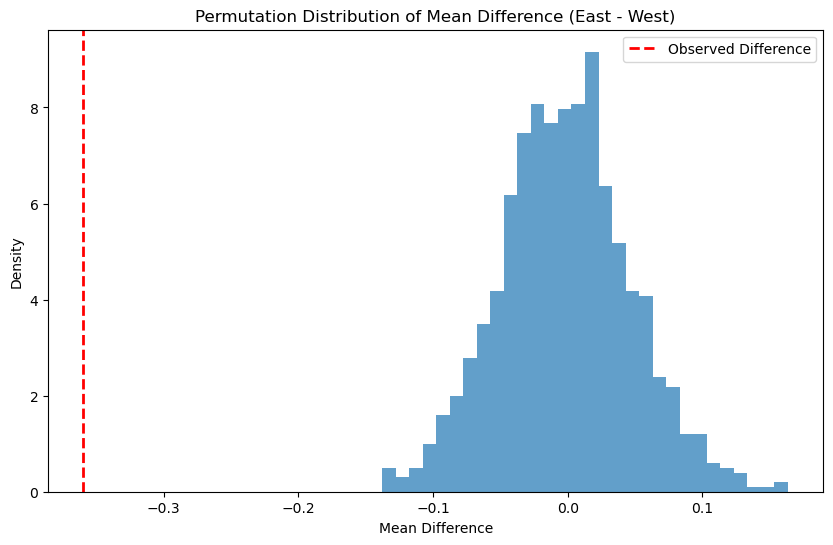

In [53]:
plt.figure(figsize=(10,6))
plt.hist(diffs_perm, bins=30, density=True, alpha=0.7)
plt.axvline(o_diff, color='red', linestyle='--', linewidth=2, label='Observed Difference')

plt.title("Permutation Distribution of Mean Difference (East - West)")
plt.xlabel("Mean Difference")
plt.ylabel("Density")
plt.legend()
plt.show()


### CLT Approach

Summarize how you'll approximate the sampling distribution analytically (e.g., using SE formulas).

The CLT specifically applies to sample means, not medians. Unlike means (where SE = σ/√n), there is no simple analytical formula for the standard error of a median. 

In [56]:
t_stat, p_two_sided = stats.ttest_ind(east_data, west_data, equal_var=False)

print(f"t-test results:")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  Two-sided p-value: {p_two_sided:.4f}")

p_one_sided = p_two_sided / 2 if t_stat > 0 else 1 - (p_two_sided / 2)

print(f"  One-sided p-value: {p_one_sided:.4f}")

t-test results:
  t-statistic: -7.9053
  Two-sided p-value: 0.0000
  One-sided p-value: 1.0000


### Comparison

Discuss how the computational and CLT approaches align or diverge.

For this analysis, I deliberately tested whether East had a higher mean progressivism than West, even though the sample size of East was much smaller than West. Using the computational approach, I calculated the observed difference in means (East – West) and compared it to a distribution of differences generated by shuffling the data. The resulting p-value was 0.000 for the two-sided test, indicating that the means are significantly different overall. 

Using the CLT approach (t-test), I obtained a t-statistic of -7.905 and a two-sided p-value of 0.000, which aligns with the permutation result: the overall means are significantly different. The negative t-statistic reflects that the mean of East is less than the mean of West. For the one-sided test corresponding to my original hypothesis (East > West), the p-value is 1.0, confirming that the data does not support East being greater than West.

In summary, both approaches lead to the same conclusion. The two-sided test indicates a significant difference between East and West. The one-sided test shows that my deliberately chosen hypothesis (East > West) is not supported. Since the one-sided p-value is greater than 0.05, we cannot reject the null hypothesis for East > West. This illustrates how the choice between one-sided and two-sided tests affects interpretation and why it is important to align the test with the hypothesis.

## Task 5

If this task is going to be a hypothesis test, briefly describe the hypothesis and dataset. If this task is going to be the calculation of an uncertainty, describe the metric and data. If this is the uncertainty calculation where you'll choose an additional metric other than the mean or a proportion, describe that metric as well.  

Uncertainty estimation (confidence intervals) for the East vs West progressivism. For the CLT-inspired approach, the natural choice is the mean. For the computational approach, I picked the median. 

### Computational Approach

Outline the resampling or permutation workflow you'll use.

In [61]:
# Your code here
boots = 1000
bootstrap_median_east = np.empty(boots)
bootstrap_median_west = np.empty(boots)


for i in range(boots):
    bootstrap_median_east[i] = np.median(np.random.choice(east_data, size=len(east_data), replace=True))
    bootstrap_median_west[i] = np.median(np.random.choice(west_data, size=len(west_data), replace=True))

ci_median_east = np.percentile(bootstrap_median_east, [2.5, 97.5])
ci_median_west = np.percentile(bootstrap_median_west, [2.5, 97.5])

median_east = np.median(east_data)
median_west = np.median(west_data)

print(f"East median: {median_east:.3f}, 95% bootstrap CI: {ci_median_east}")
print(f"West median: {median_west:.3f}, 95% bootstrap CI: {ci_median_west}")

East median: 0.583, 95% bootstrap CI: [0.5        0.64583333]
West median: 0.875, 95% bootstrap CI: [0.83333333 0.95833333]


### CLT Approach

Summarize how you'll approximate the sampling distribution analytically (e.g., using SE formulas).

In [66]:
# Your code here
mean_east = east_data.mean()
se_east = east_data.std(ddof=1) / np.sqrt(len(east_data))
tcrit_east = stats.t.ppf(0.975, df=len(east_data)-1)
ci_east = (mean_east - tcrit_east*se_east, mean_east + tcrit_east*se_east)

mean_west = west_data.mean()
se_west = west_data.std(ddof=1) / np.sqrt(len(west_data))
tcrit_west = stats.t.ppf(0.975, df=len(west_data)-1)
ci_west = (mean_west - tcrit_west*se_west, mean_west + tcrit_west*se_west)

print(f"East mean: {mean_east:.3f}, 95% CI: [{ci_east[0]:.3f} {ci_east[1]:.3f}]")
print(f"West mean: {mean_west:.3f}, 95% CI: [{ci_west[0]:.3f} {ci_west[1]:.3f}]")

East mean: 0.635, 95% CI: [0.557 0.712]
West mean: 0.994, 95% CI: [0.950 1.038]


### Comparison

Discuss how the computational and CLT approaches align or diverge.

Using the computational bootstrap approach, we estimated the median progressivism for East and West WA regions. East has a median of 0.583 with a 95% bootstrap CI of [0.500, 0.646], while West has a median of 0.875 with a 95% CI of [0.833, 0.958]. 

These intervals do not overlap, showing a clear difference between the regions. Using the CLT approach, we calculated the mean progressivism and its 95% confidence interval: East has a mean of 0.635 (CI: [0.557, 0.712]) and West has a mean of 0.994 (CI: [0.950, 1.038]). 

Both approaches indicate that West has higher progressivism scores than East and the difference is clear because the West sample is larger than the East sample.

## Reflection

- Having done these analyses in two ways, what are your thoughts on the process?
- It's Prof. Chandler's contention that doing computational approaches is better because it gues you in touch with the details of the null hypothesis and where the p-value comes from. How does it seem to you? (To be clear, feel _free_ to disagree with me!)
- To what extent did you find an interesting additional metric to do bootstrapping on? In other words, for the metric you chose that _wasn't_ a proportion or mean, is that metric interesting? If it is, say why and tell me how hard it was to come up with. If not, tell me why it was hard for you to come up with a metric that was intrinsically interesting. 


#### Write your reflection below here



I preferred the computational approach because the CLT method mostly involved plugging values into formulas. The computational (permutation/bootstrapping) methods felt more intuitive because you can see exactly how the null hypothesis works and how the p-value arises from shuffling or resampling the data. I chose the median as an alternative metric since it is more robust than the mean, especially because in the imbalance in sample sizes.